**VIX in the one-factor Bergomi model**

# Imports

In [1]:
# TODO: try to calibrate the single case model to VIX data

In [2]:
%load_ext autoreload
%autoreload 2

In [50]:
import matplotlib.pyplot as plt
from bergomi import OneFactorBergomi
import matplotlib as mpl
import numpy as np
import seaborn as sns
from utils import relative_error

sns.set_theme(context="talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)
SEED = 1234
COLORS = sns.color_palette("tab10")

In [51]:
mats = {
    # "1W": 7 / 365.0,
    "1M": 1.0 / 12.0,
    "3M": 3.0 / 12.0,
    "6M": 6.0 / 12.0,
    # "1Y": 1.0,
}

# Single case

## VIX implied volatility

In [62]:
# model parameters

set_name = "set_2"

params = {
    "set_1": {"w": 2.0, "k": 0.25},
    "set_2": {
        "w": 8.0,
        "k": 10,
    },  # set 2, from Guyon, "The VIX Future in Bergomi Models"
}

rho = -0.7
xi0 = lambda u: np.ones_like(u) * 0.24**2
# xi0 = lambda t: xi0_heston(t, shape="contango")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params[set_name])

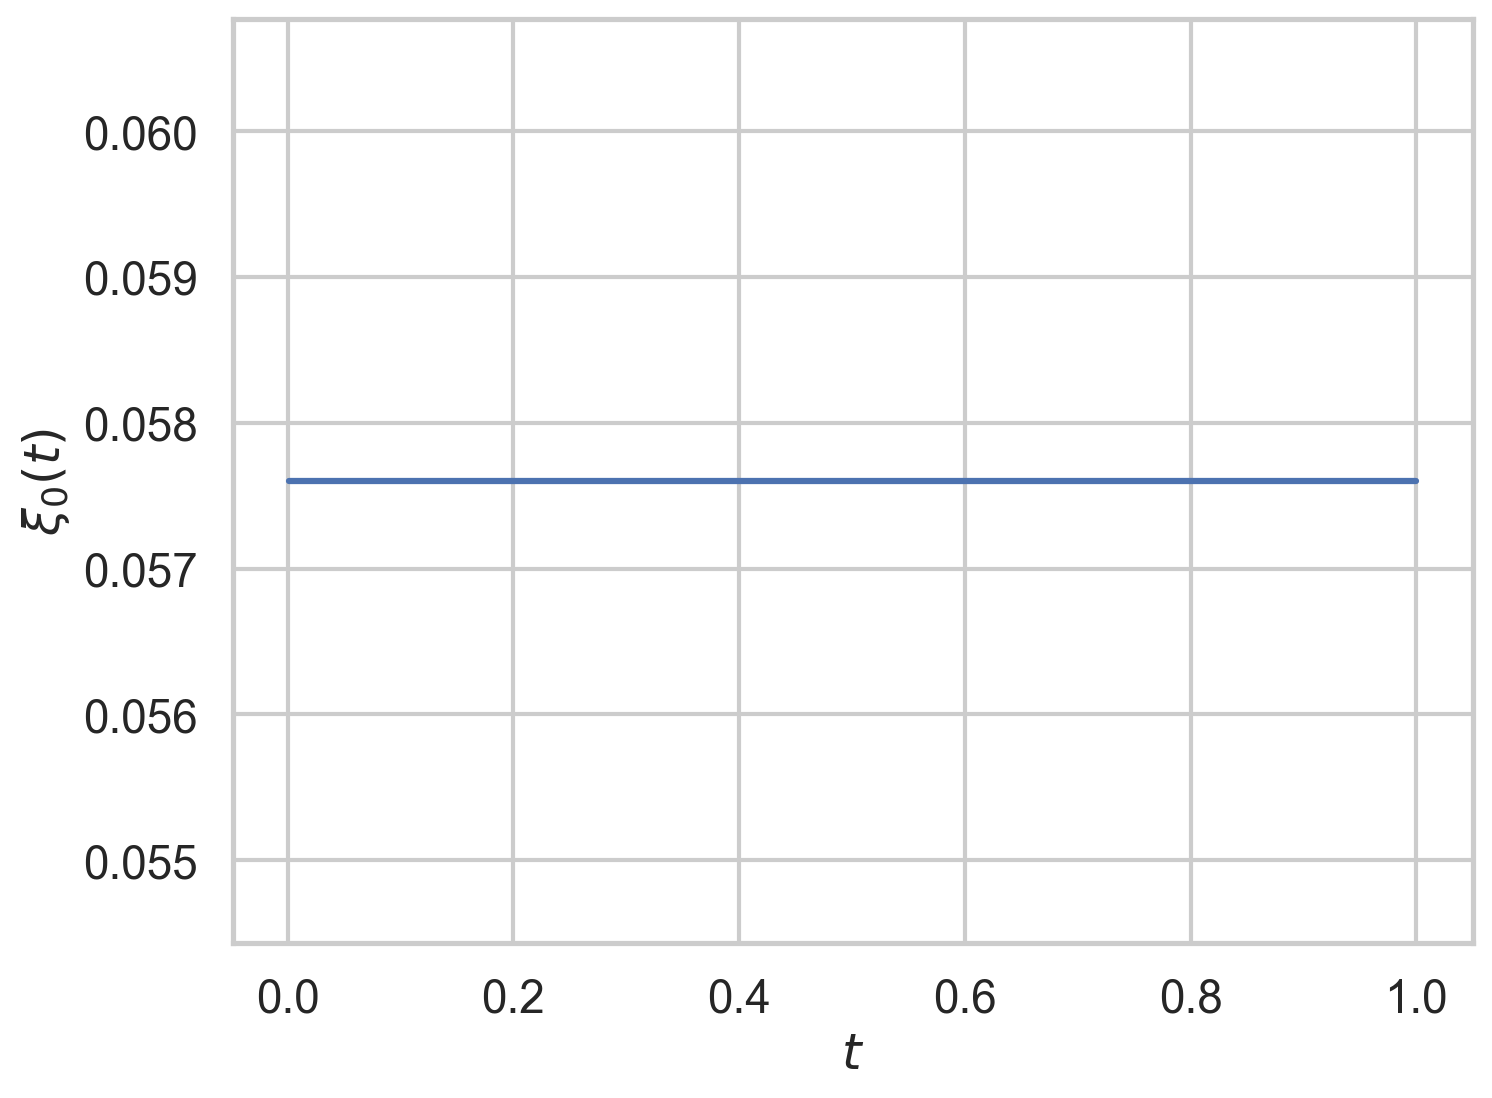

In [63]:
# plot xi0
ts = np.linspace(1e-3, 1.0, 101)
fig, ax = plt.subplots()
ax.plot(ts, onebergomi.xi0(ts))
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\xi_0(t)$")
plt.show()

In [64]:
# log moneyness
ks = np.linspace(-0.1, 0.4, 10)

In [65]:
# VIX implied volatilities via quadrature
n_quad = 120
impvol_vix = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad)
    for month, T in mats.items()
}

In [66]:
# VIX implied vol from weak approximation
impvol_vix_approx = {
    month: onebergomi.implied_vol_vix_approx(k=ks, T=T, order=3)
    for month, T in mats.items()
}

In [67]:
# VIX implied vol from expansion formula
impvol_vix_expansion = {
    month: onebergomi.implied_vol_vix_expansion(k=ks, T=T, order=1)
    for month, T in mats.items()
}

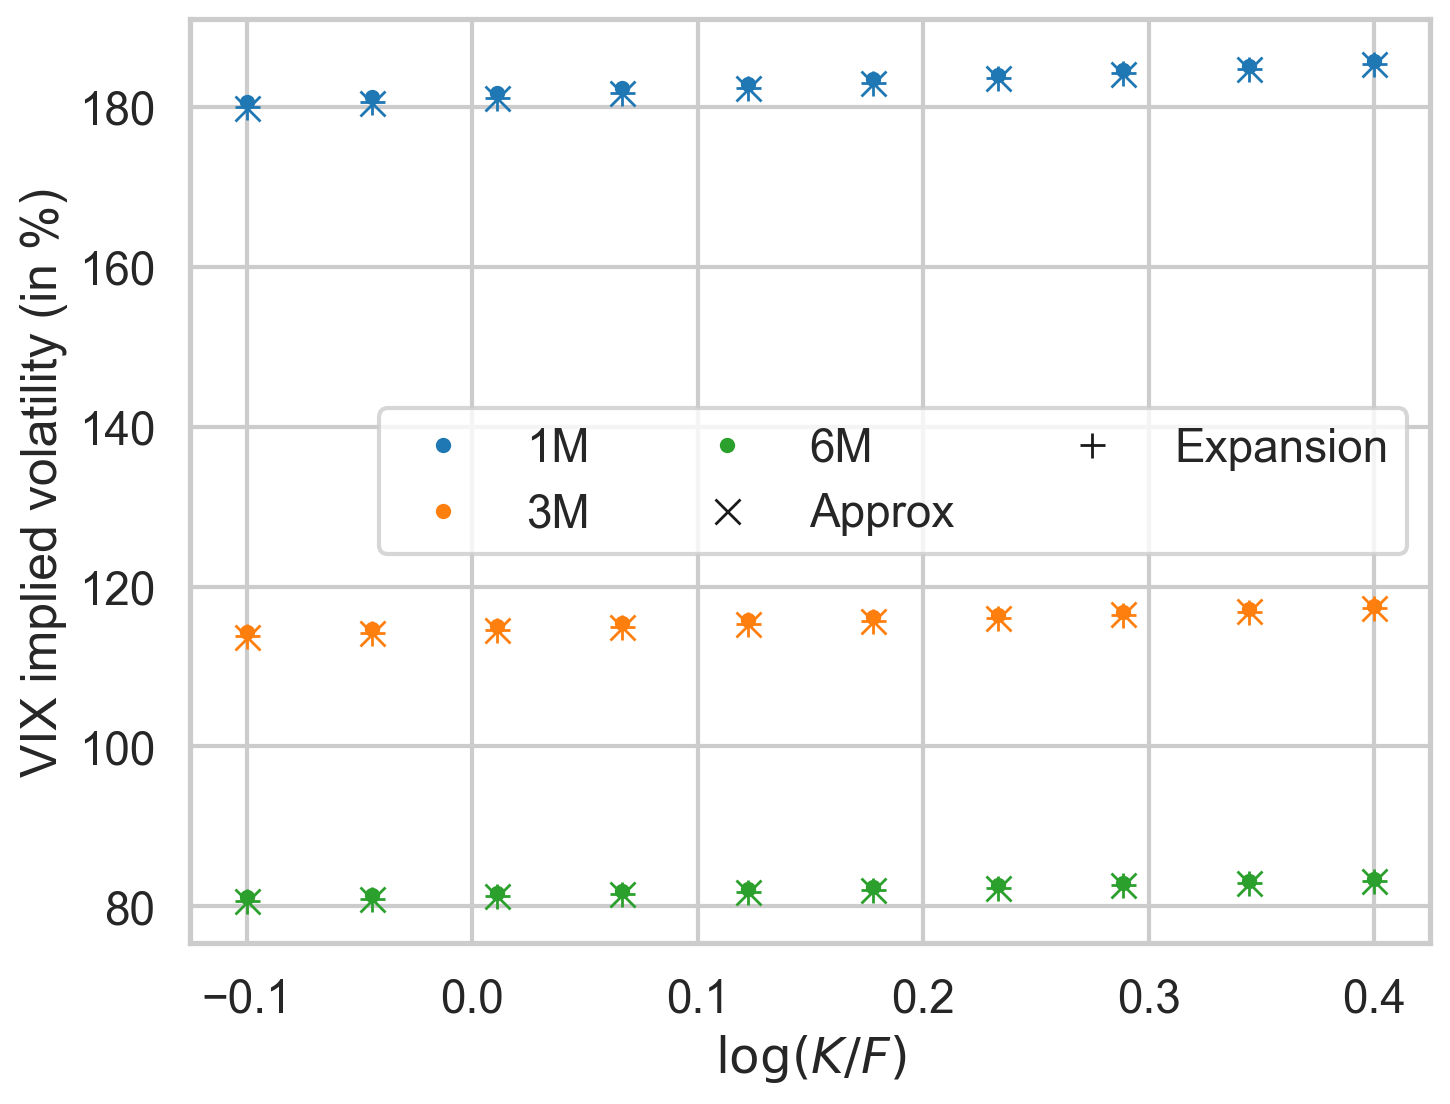

In [72]:
fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 1e2 * impvol_vix[month], ".", color=COLORS[i], label=f"{month}")
    ax.plot(ks, 1e2 * impvol_vix_approx[month], "x", color=COLORS[i])
    ax.plot(ks, 1e2 * impvol_vix_expansion[month], "+", color=COLORS[i])
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$\log(K/F)$")
ax.set_ylabel("VIX implied volatility (in %)")
ax.legend(ncol=3)
# ax.set_ylim(92, 100)
# fig.savefig(f"figures/vix_one_bergomi_{set_name}.pdf", bbox_inches="tight")
plt.show()

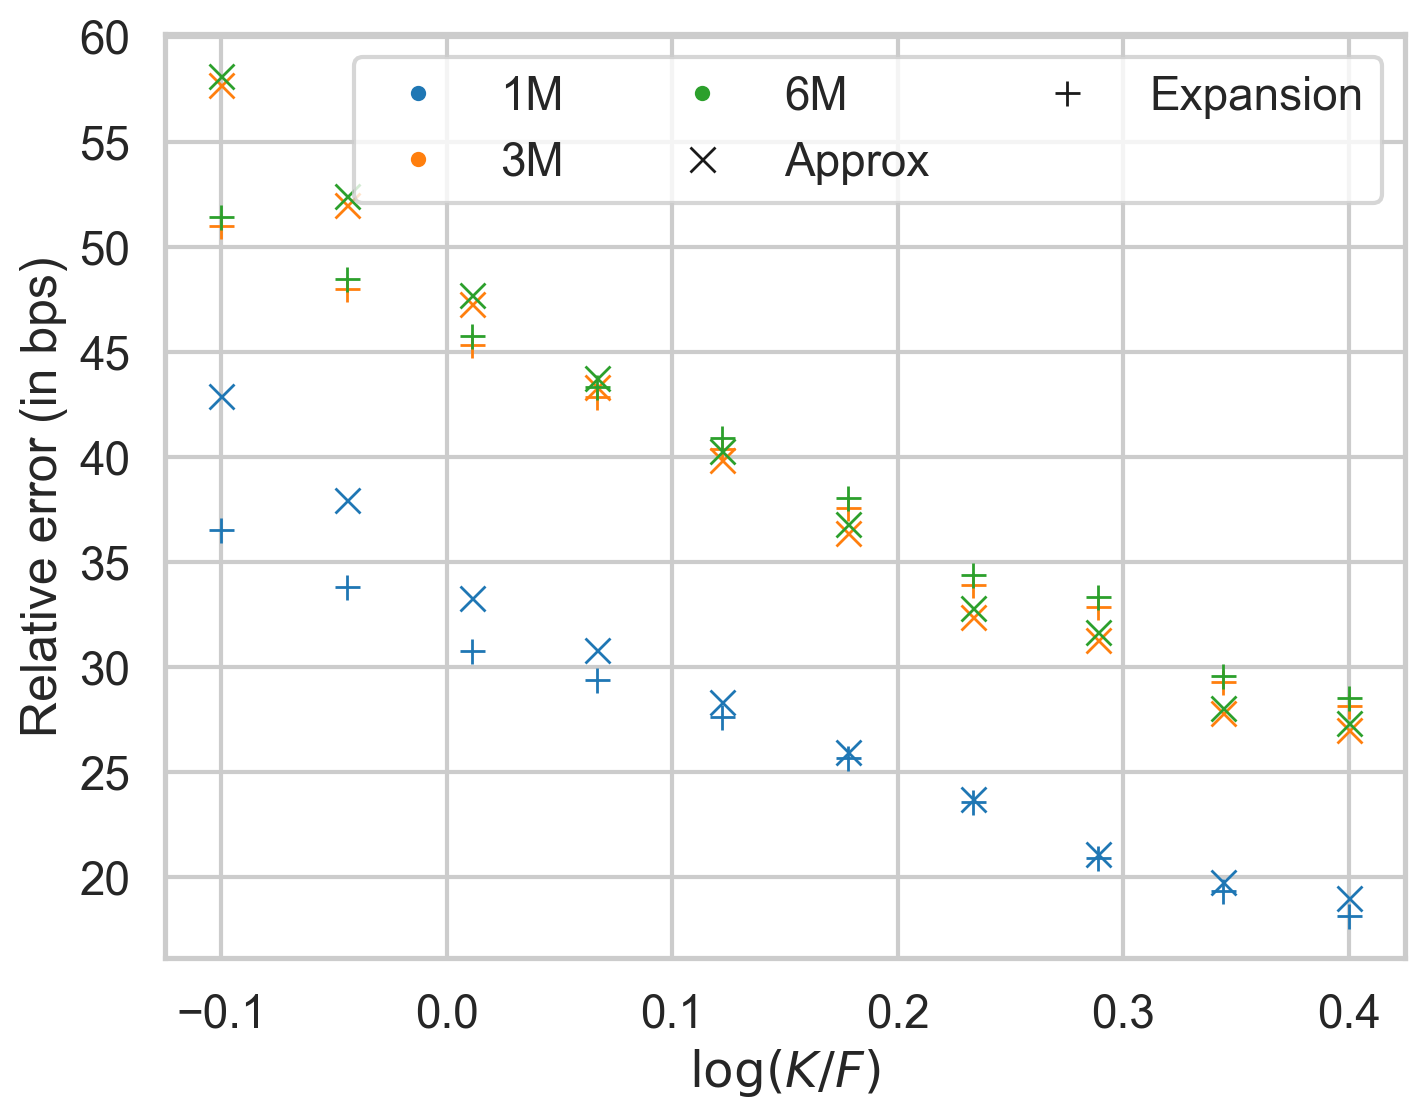

In [73]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_approx[month], impvol_vix[month]) for month in mats
]
rel_error_expansion = [
    relative_error(impvol_vix_expansion[month], impvol_vix[month]) for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, 1e4 * rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, 1e4 * rel_error_expansion[i], "+", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.set_xlabel(r"$\log(K/F)$")
ax.set_ylabel("Relative error (in bps)")
ax.legend(loc="best", ncol=3)
# ax.set_ylim(-0.05, 0.05)
# plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
fig.savefig(f"figures/vix_one_bergomi_error_{set_name}.pdf", bbox_inches="tight")
plt.show()

# Mixed case

In [7]:
# params = {"w": 10.0, "k": 1}
# lbd = 0.2
# w_2 = 2.0
# rho = -0.7
params = {"w": 0.5, "k": 1}
lbd = 0.3
w_2 = 6.0
rho = -0.7
xi0 = lambda u: np.ones_like(u) * 0.2**2
# xi0 = lambda t: xi0_heston(t, shape="contango")

onebergomi = OneFactorBergomi(rho=rho, xi0=xi0, params=params)
ks = np.linspace(-0.1, 0.4, 10)

In [8]:
# VIX implied volatilities
n_quad = 120
impvol_vix_mixed = {
    month: onebergomi.implied_vol_vix(k=ks, T=T, n_quad=n_quad, lbd=lbd, w_2=w_2)
    for month, T in mats.items()
}

In [9]:
# Weak approximation
impvol_vix_mixed_approx = {
    month: np.asarray(
        onebergomi.implied_vol_vix_approx_mixed(
            lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0, n_quad=n_quad
        )
    )
    for month, T in mats.items()
}

In [29]:
# # Hermite series
# impvol_vix_mixed_approx_series = {
#     month: np.asarray(
#         onebergomi.implied_vol_vix_approx_mixed(
#             lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0, n_trunc_herm=4
#         )
#     )
#     for month, T in mats.items()
# }

In [23]:
# maybe adjust formula depending on call/put and sigma_1 / sigma_2
# TODO: try to start from formula directly and use hermite expansion

implied_vol_vix_expansion = {
    month: np.array(
        [
            onebergomi.implied_vol_vix_expansion_mixed(
                k=k, T=T, lbd=lbd, volvol_2=w_2, n_trunc_herm=5, opt=0
            )
            for k in ks
        ]
    )
    for month, T in mats.items()
}

In [24]:
# # Lognormal approximation
# impvol_vix_mixed_approx_lognorm = {
#     month: np.asarray(
#         onebergomi.implied_vol_vix_lognorm_approx_mixed(
#             lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
#         )
#     )
#     for month, T in mats.items()
# }

In [25]:
# # Shifted Lognormal approximation
# impvol_vix_mixed_approx_slognorm = {
#     month: np.asarray(
#         onebergomi.implied_vol_vix_shifted_lognorm_approx_mixed(
#             lbd=lbd, volvol_2=w_2, k=ks, T=T, order=0
#         )
#     )
#     for month, T in mats.items()
# }

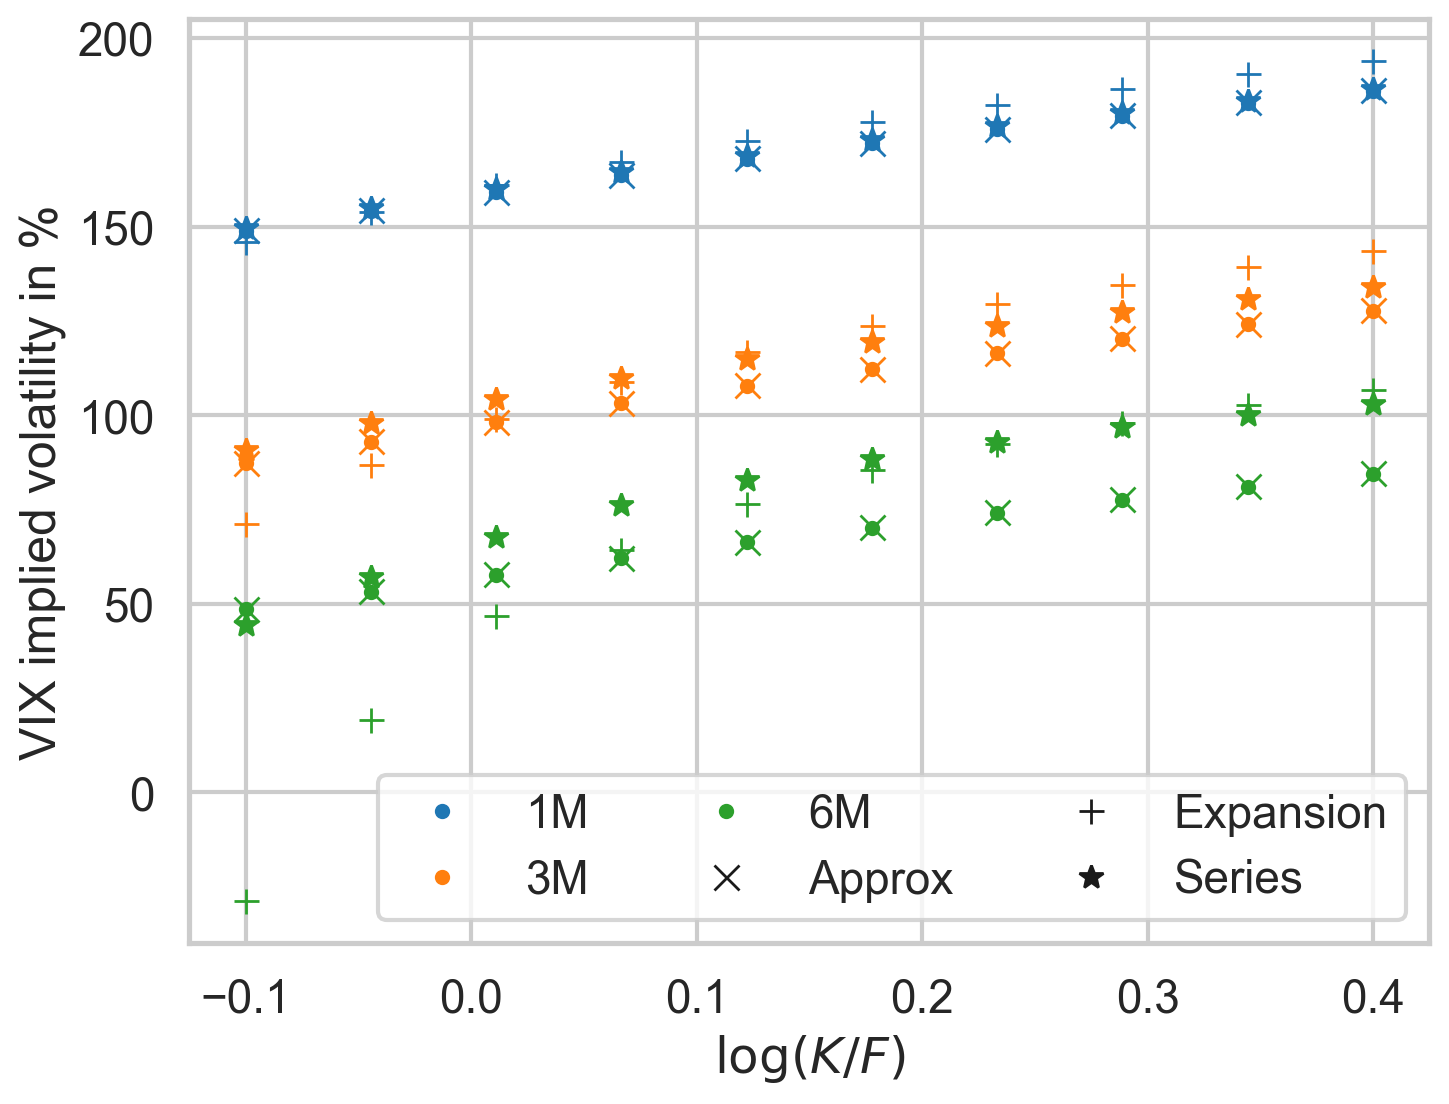

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, month in enumerate(mats.keys()):
    ### True VIX implied volatilities
    ax.plot(
        ks,
        100 * impvol_vix_mixed[month],
        ".",
        color=COLORS[i],
        label=f"{month}",
    )
    ### Weak approximation
    ax.plot(
        ks,
        100 * impvol_vix_mixed_approx[month],
        "x",
        color=COLORS[i],
    )
    # Expansion formula
    ax.plot(
        ks,
        100 * implied_vol_vix_expansion[month],
        "+",
        color=COLORS[i],
    )
    # ## Hermite series approximation
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_series[month],
    #     "*",
    #     color=COLORS[i],
    # )
    ### Lognormal approximation
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_lognorm[month],
    #     "v",
    #     color=COLORS[i],
    # )
    ### Shifted lognormal approximation
    # ax.plot(
    #     ks,
    #     100 * impvol_vix_mixed_approx_slognorm[month],
    #     "*",
    #     color=COLORS[i],
    # )
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k+", label="Expansion")
ax.plot([], [], "k*", label="Series")
ax.set_xlabel(r"$\log(K/F)$")
ax.set_ylabel("VIX implied volatility in %")
ax.legend(ncol=3)
# ax.set_ylim(10, 150)
plt.show()

{'1M': array([0.31482451, 0.33447839, 0.35958521, 0.39275117, 0.42756878,
        0.46228312, 0.49608134, 0.52865841, 0.5599352 , 0.58992557,
        0.61867811, 0.64625196, 0.67270704, 0.69809996, 0.72248243]),
 '3M': array([0.23102768, 0.24187945, 0.25704958, 0.28052233, 0.30605324,
        0.33178903, 0.35688303, 0.38104497, 0.40421613, 0.42642005,
        0.44770576, 0.46812691, 0.48773445, 0.50657518, 0.52469067]),
 '6M': array([0.17173503, 0.17893177, 0.18941153, 0.20660181, 0.22555362,
        0.24473805, 0.26345212, 0.28146129, 0.29872242, 0.31525765,
        0.33110742, 0.34631427, 0.36091801, 0.37495438, 0.38845506]),
 '1Y': array([0.12229513, 0.12732457, 0.13469864, 0.14690977, 0.1604018 ,
        0.17406892, 0.18740188, 0.20023141, 0.21252688, 0.22430468,
        0.23559388, 0.24642538, 0.25682751, 0.26682589, 0.27644318])}

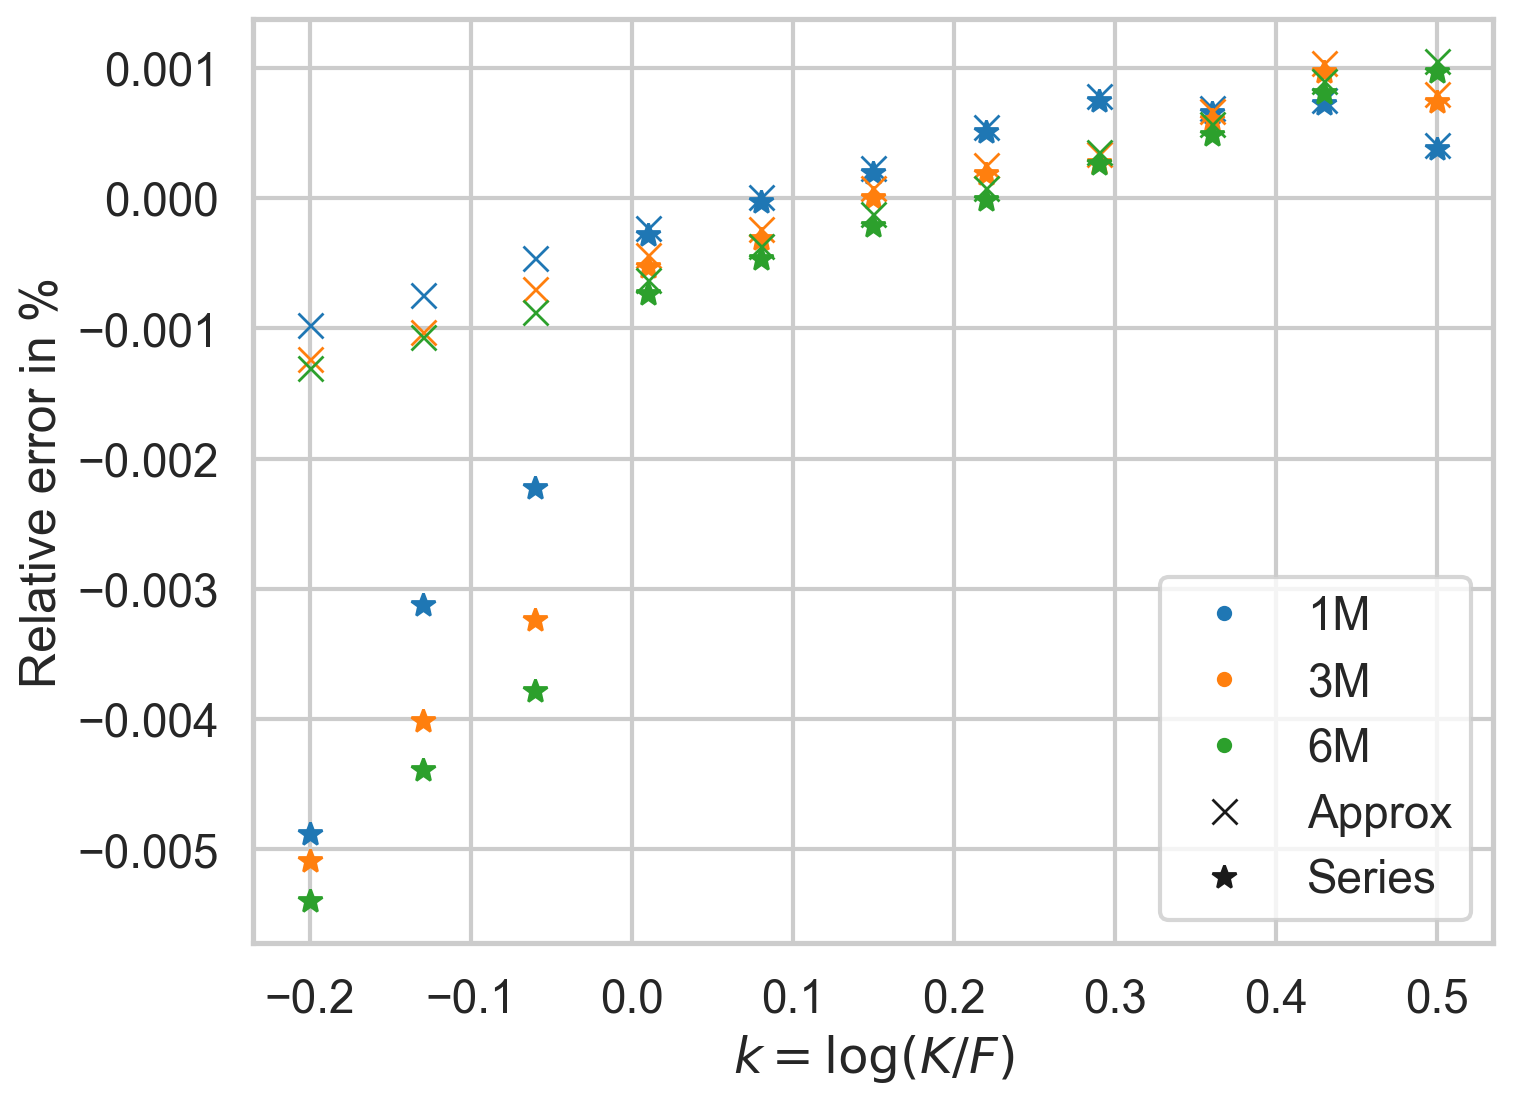

In [106]:
# relative errors
rel_error_approx = [
    relative_error(impvol_vix_mixed_approx[month], impvol_vix_mixed[month])
    for month in mats
]
rel_error_approx_series = [
    relative_error(impvol_vix_mixed_approx_series[month], impvol_vix_mixed[month])
    for month in mats
]

fig, ax = plt.subplots()
for i, month in enumerate(mats.keys()):
    ax.plot(ks, rel_error_approx[i], "x", color=COLORS[i])
    ax.plot(ks, rel_error_approx_series[i], "*", color=COLORS[i])
    ax.plot([], [], ".", color=COLORS[i], label=f"{month}")
ax.plot([], [], "kx", label="Approx")
ax.plot([], [], "k*", label="Series")
ax.set_xlabel(r"$k=\log(K/F)$")
ax.set_ylabel("Relative error in %")
ax.legend(loc="best")
# ax.set_ylim(-1e-3, 1e-3)
plt.show()